# Customer Segmentation Using Unsupervised Learning

## 1. Problem Statement and Objective
This project uses unsupervised learning to segment mall customers based on spending behavior, annual income, and age. The goal is to discover meaningful customer groups and translate each group into a targeted marketing strategy.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "dataset" / "Mall_Customers.csv"
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

WindowsPath('D:/Customer Segmentation Using Unsupervised Learning/dataset/Mall_Customers.csv')

## 2. Dataset Description and Loading
The primary dataset is `dataset/Mall_Customers.csv`. It contains `CustomerID`, `Gender` or `Genre`, `Age`, `Annual Income (k$)`, and `Spending Score (1-100)`.

In [2]:
df = pd.read_csv(DATA_PATH)
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(f"Rows: {df.shape[0]} | Columns: {df.shape[1]}")
df.info()

Rows: 200 | Columns: 5
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


## 3. Data Cleaning and Preprocessing
We inspect data quality, rename columns into clean names, encode gender for analysis where useful, select numeric clustering features, and apply feature scaling.

In [4]:
print("Shape:", df.shape)
print("Missing values:")
display(df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Data types:")
display(df.dtypes)

Shape: (200, 5)
Missing values:


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Duplicate rows: 0
Data types:


CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

In [5]:
clean_df = df.copy()
clean_df = clean_df.rename(columns={
    "Genre": "Gender",
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score",
})

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

if "Gender" in clean_df.columns:
    clean_df["Gender"] = clean_df["Gender"].astype(str).str.strip()
    encoder = LabelEncoder()
    clean_df["Gender_Encoded"] = encoder.fit_transform(clean_df["Gender"])

features = ["Age", "Annual_Income", "Spending_Score"]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(clean_df[features])

clean_df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


## 4. Exploratory Data Analysis
The following charts examine customer demographics, income, spending behavior, relationships between variables, correlations, and potential outliers.

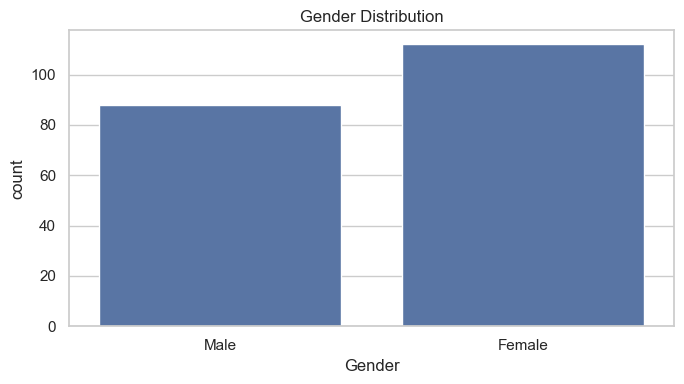

In [6]:
def save_current_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(data=clean_df, x="Gender")
plt.title("Gender Distribution")
save_current_figure("gender_distribution.png")

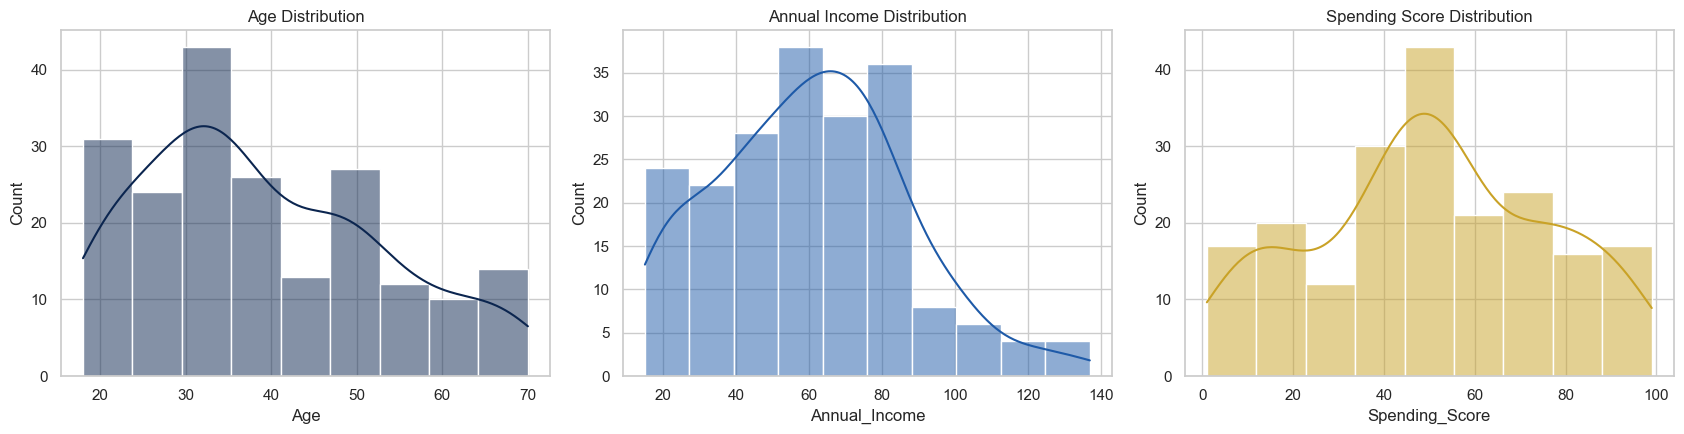

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sns.histplot(clean_df["Age"], kde=True, ax=axes[0], color="#0B254F")
axes[0].set_title("Age Distribution")
sns.histplot(clean_df["Annual_Income"], kde=True, ax=axes[1], color="#1E5AA8")
axes[1].set_title("Annual Income Distribution")
sns.histplot(clean_df["Spending_Score"], kde=True, ax=axes[2], color="#C9A227")
axes[2].set_title("Spending Score Distribution")
save_current_figure("numeric_distributions.png")

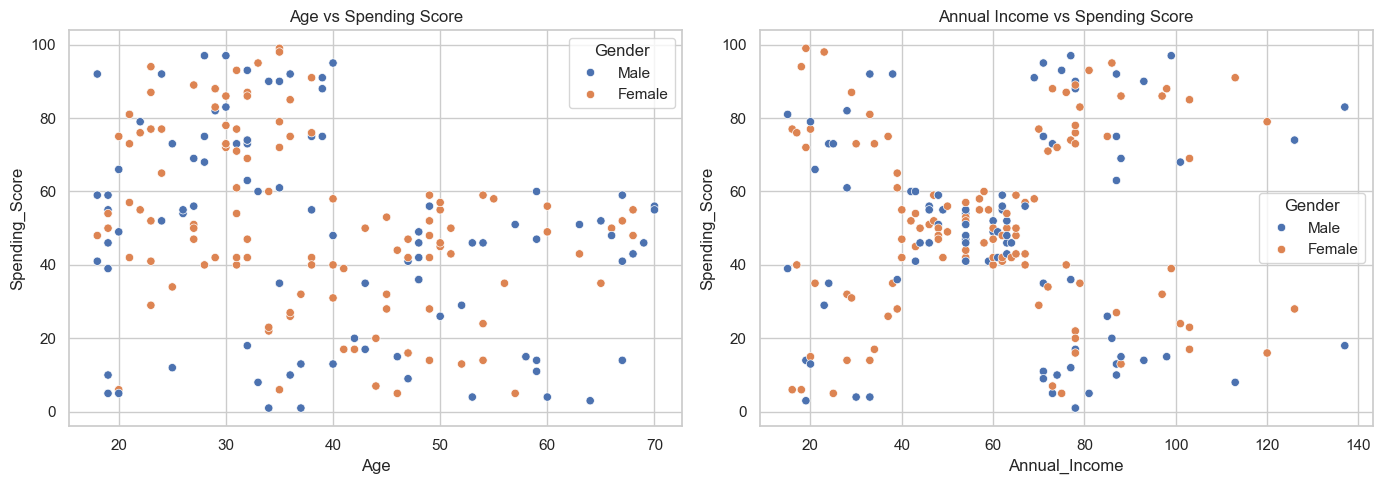

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=clean_df, x="Age", y="Spending_Score", hue="Gender", ax=axes[0])
axes[0].set_title("Age vs Spending Score")
sns.scatterplot(data=clean_df, x="Annual_Income", y="Spending_Score", hue="Gender", ax=axes[1])
axes[1].set_title("Annual Income vs Spending Score")
save_current_figure("scatter_relationships.png")

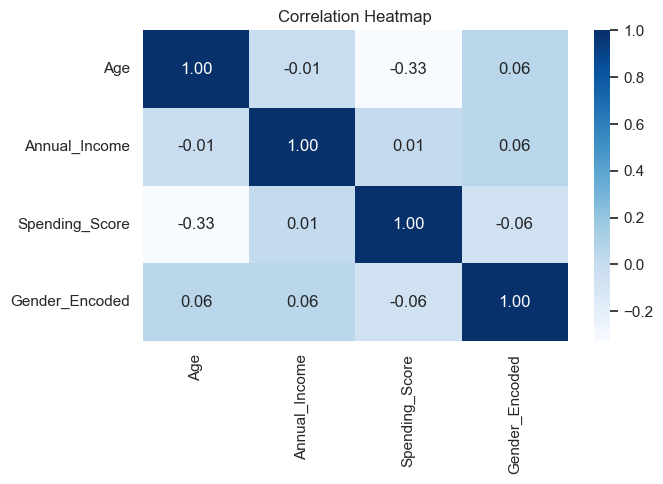

In [9]:
plt.figure(figsize=(7, 5))
sns.heatmap(clean_df[["Age", "Annual_Income", "Spending_Score", "Gender_Encoded"]].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
save_current_figure("correlation_heatmap.png")

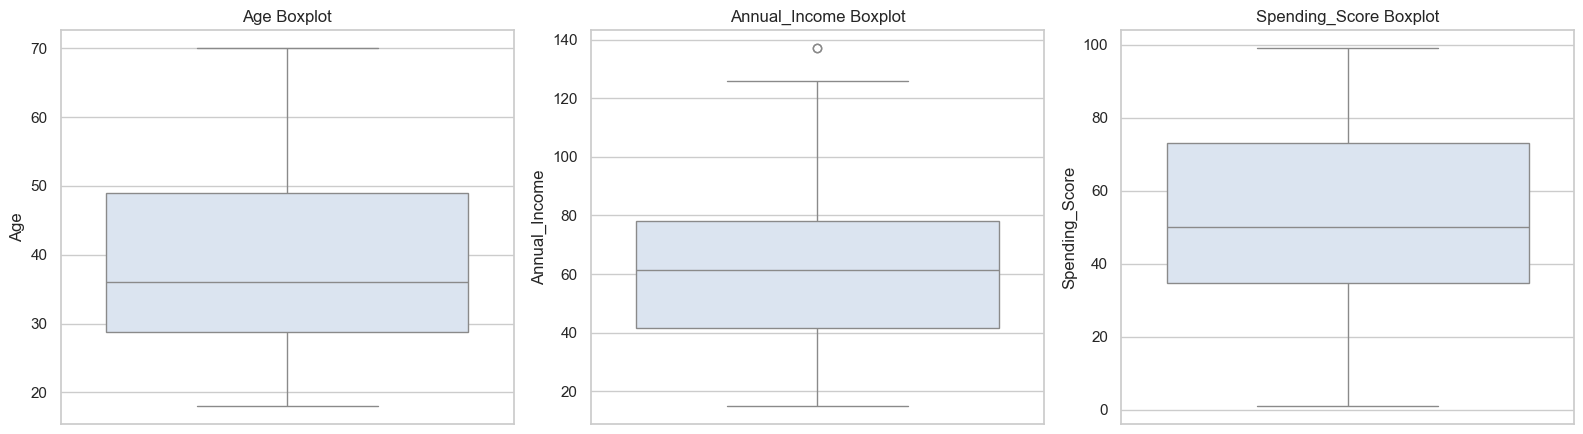

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, features):
    sns.boxplot(y=clean_df[col], ax=ax, color="#D8E3F3")
    ax.set_title(f"{col} Boxplot")
save_current_figure("boxplots_outliers.png")

## 5. K-Means Clustering
We use the Elbow Method and Silhouette Score to evaluate candidate values of K. For the Mall Customers dataset, K=5 is a strong and interpretable business default.

In [11]:
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_features)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(scaled_features, labels))

evaluation_df = pd.DataFrame({"K": list(k_values), "Inertia": inertias, "Silhouette_Score": silhouette_scores})
evaluation_df

,K,Inertia,Silhouette_Score
0,2,389.386189,0.335472
1,3,295.212246,0.357793
2,4,205.225147,0.403958
3,5,168.247580,0.416643
4,6,133.868421,0.428417
5,7,117.011555,0.417232
6,8,103.873292,0.408207
7,9,93.092891,0.417693
8,10,82.385154,0.406554


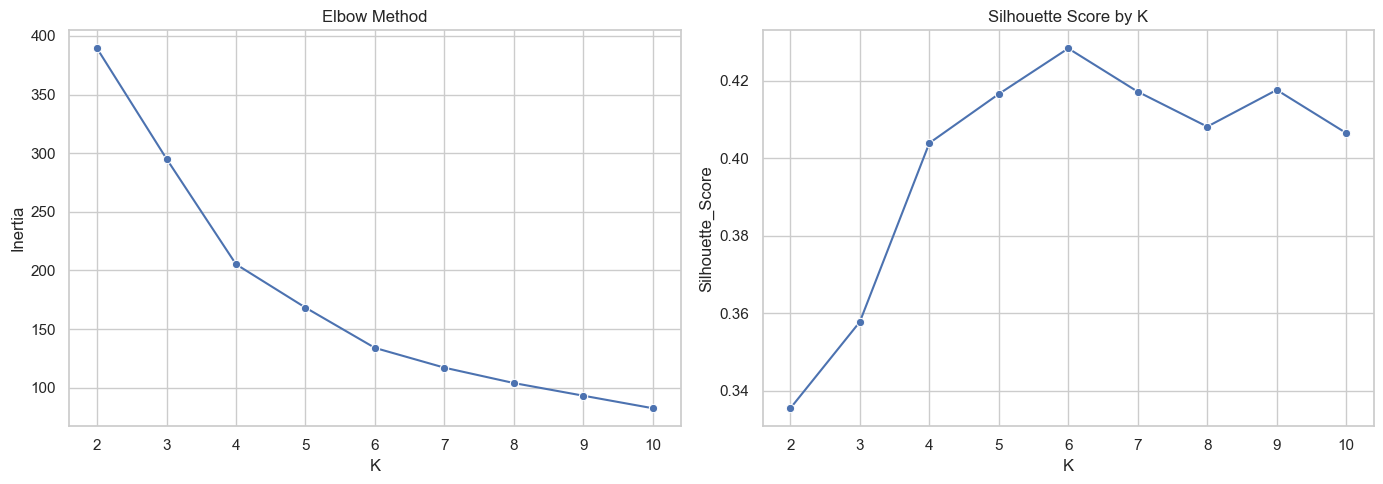

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=evaluation_df, x="K", y="Inertia", marker="o", ax=axes[0])
axes[0].set_title("Elbow Method")
sns.lineplot(data=evaluation_df, x="K", y="Silhouette_Score", marker="o", ax=axes[1])
axes[1].set_title("Silhouette Score by K")
save_current_figure("kmeans_evaluation.png")

In [13]:
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clean_df["Cluster"] = kmeans.fit_predict(scaled_features)
clean_df.to_csv(OUTPUT_DIR / "clustered_customers.csv", index=False)
print("Saved:", OUTPUT_DIR / "clustered_customers.csv")
clean_df.head()

Saved: D:\Customer Segmentation Using Unsupervised Learning\outputs\clustered_customers.csv


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Gender_Encoded,Cluster
0,1,Male,19,15,39,1,1
1,2,Male,21,15,81,1,1
2,3,Female,20,16,6,0,0
3,4,Female,23,16,77,0,1
4,5,Female,31,17,40,0,1


## 6. PCA and t-SNE Visualization
PCA and t-SNE reduce the scaled feature matrix to two dimensions so cluster separation can be viewed visually.

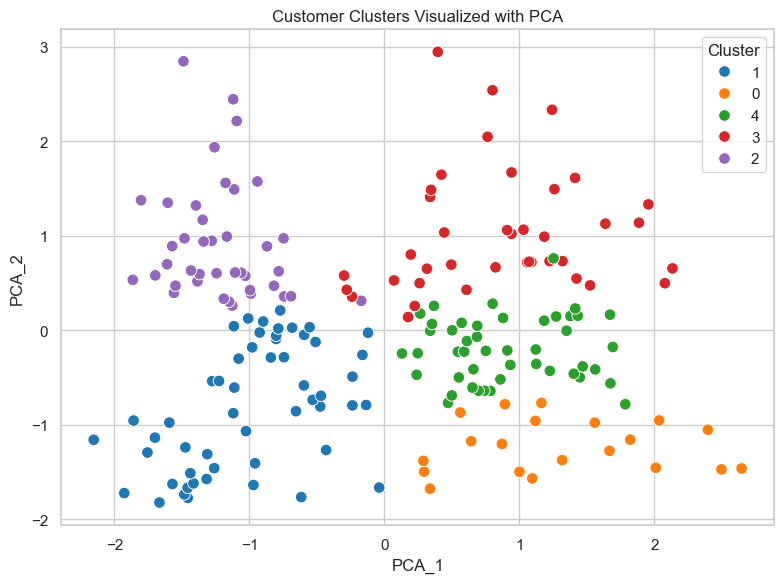

In [14]:
pca = PCA(n_components=2, random_state=42)
pca_points = pca.fit_transform(scaled_features)
pca_df = pd.DataFrame({"PCA_1": pca_points[:, 0], "PCA_2": pca_points[:, 1], "Cluster": clean_df["Cluster"].astype(str)})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PCA_1", y="PCA_2", hue="Cluster", palette="tab10", s=70)
plt.title("Customer Clusters Visualized with PCA")
save_current_figure("pca_clusters.png")

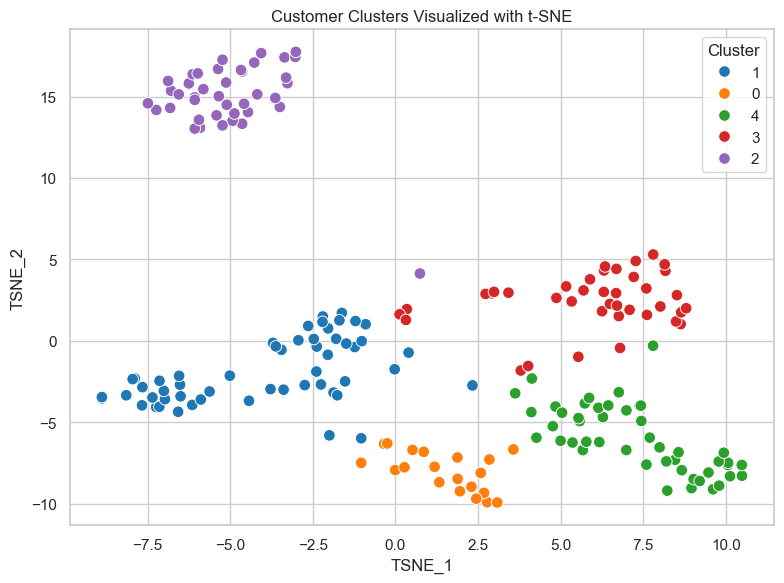

In [15]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, init="pca", learning_rate="auto")
tsne_points = tsne.fit_transform(scaled_features)
tsne_df = pd.DataFrame({"TSNE_1": tsne_points[:, 0], "TSNE_2": tsne_points[:, 1], "Cluster": clean_df["Cluster"].astype(str)})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=tsne_df, x="TSNE_1", y="TSNE_2", hue="Cluster", palette="tab10", s=70)
plt.title("Customer Clusters Visualized with t-SNE")
save_current_figure("tsne_clusters.png")

## 7. Cluster Profiling
We summarize every cluster by average age, annual income, spending score, count of customers, and gender distribution.

In [16]:
cluster_profile = clean_df.groupby("Cluster").agg(
    Average_Age=("Age", "mean"),
    Average_Annual_Income=("Annual_Income", "mean"),
    Average_Spending_Score=("Spending_Score", "mean"),
    Customer_Count=("CustomerID", "count"),
).round(2)

gender_distribution = pd.crosstab(clean_df["Cluster"], clean_df["Gender"], normalize="index").round(3)
cluster_profile = cluster_profile.join(gender_distribution)
cluster_profile

,Average_Age,Average_Annual_Income,Average_Spending_Score,Customer_Count,Female,Male
Cluster,,,,,,
0,46.25,26.75,18.35,20,0.600,0.400
1,25.19,41.09,62.24,54,0.593,0.407
2,32.88,86.10,81.53,40,0.550,0.450
3,39.87,86.10,19.36,39,0.487,0.513
4,55.64,54.38,48.85,47,0.574,0.426


## 8. Marketing Strategies
Segment names are assigned from each cluster profile using cluster-level income and spending score. This avoids hardcoding interpretations to cluster numbers.

In [17]:
STRATEGIES = {
    "Premium Customers": "VIP offers, exclusive membership, early access, and personalized recommendations.",
    "Potential Customers": "Targeted discounts, product demos, premium bundles, and conversion campaigns.",
    "Deal Seekers": "Cashback, loyalty points, affordable bundles, and seasonal promotions.",
    "Budget Customers": "Low-cost offers, basic packages, student discounts, and value deals.",
    "Standard Customers": "Retention campaigns, loyalty cards, regular promotions, and cross-sell offers.",
}

def assign_segment(row, income_median, spending_median):
    high_income = row["Average_Annual_Income"] >= income_median
    high_spending = row["Average_Spending_Score"] >= spending_median
    if high_income and high_spending:
        return "Premium Customers"
    if high_income and not high_spending:
        return "Potential Customers"
    if not high_income and high_spending:
        return "Deal Seekers"
    if not high_income and not high_spending:
        return "Budget Customers"
    return "Standard Customers"

income_median = cluster_profile["Average_Annual_Income"].median()
spending_median = cluster_profile["Average_Spending_Score"].median()
cluster_profile["Segment_Name"] = cluster_profile.apply(assign_segment, axis=1, income_median=income_median, spending_median=spending_median)
cluster_profile["Marketing_Strategy"] = cluster_profile["Segment_Name"].map(STRATEGIES)
cluster_profile.to_csv(OUTPUT_DIR / "cluster_profile.csv")
print("Saved:", OUTPUT_DIR / "cluster_profile.csv")
cluster_profile

Saved: D:\Customer Segmentation Using Unsupervised Learning\outputs\cluster_profile.csv


,Average_Age,Average_Annual_Income,Average_Spending_Score,Customer_Count,Female,Male,Segment_Name,Marketing_Strategy
Cluster,,,,,,,,
0,46.25,26.75,18.35,20,0.600,0.400,Budget Customers,"Low-cost offers, basic packages, student disco..."
1,25.19,41.09,62.24,54,0.593,0.407,Deal Seekers,"Cashback, loyalty points, affordable bundles, ..."
2,32.88,86.10,81.53,40,0.550,0.450,Premium Customers,"VIP offers, exclusive membership, early access..."
3,39.87,86.10,19.36,39,0.487,0.513,Potential Customers,"Targeted discounts, product demos, premium bun..."
4,55.64,54.38,48.85,47,0.574,0.426,Premium Customers,"VIP offers, exclusive membership, early access..."


In [18]:
for cluster_id, row in cluster_profile.iterrows():
    print(f"Cluster {cluster_id}: {row['Segment_Name']}")
    print(f"Average age: {row['Average_Age']:.1f}")
    print(f"Average annual income: {row['Average_Annual_Income']:.1f}")
    print(f"Average spending score: {row['Average_Spending_Score']:.1f}")
    print(f"Recommended strategy: {row['Marketing_Strategy']}\n")

Cluster 0: Budget Customers
Average age: 46.2
Average annual income: 26.8
Average spending score: 18.4
Recommended strategy: Low-cost offers, basic packages, student discounts, and value deals.

Cluster 1: Deal Seekers
Average age: 25.2
Average annual income: 41.1
Average spending score: 62.2
Recommended strategy: Cashback, loyalty points, affordable bundles, and seasonal promotions.

Cluster 2: Premium Customers
Average age: 32.9
Average annual income: 86.1
Average spending score: 81.5
Recommended strategy: VIP offers, exclusive membership, early access, and personalized recommendations.

Cluster 3: Potential Customers
Average age: 39.9
Average annual income: 86.1
Average spending score: 19.4
Recommended strategy: Targeted discounts, product demos, premium bundles, and conversion campaigns.

Cluster 4: Premium Customers
Average age: 55.6
Average annual income: 54.4
Average spending score: 48.9
Recommended strategy: VIP offers, exclusive membership, early access, and personalized recom

## 9. Final Conclusion
This project cleaned and explored the Mall Customers dataset, scaled key behavioral features, evaluated K-Means cluster counts, and used K=5 for interpretable customer segmentation. PCA and t-SNE visualizations confirmed visible customer groups. Cluster profiles were converted into business-friendly segment names and marketing strategies, giving companies a practical framework for campaign targeting, retention, upselling, and customer relationship management.